<a href="https://colab.research.google.com/github/nknak-crypto/Machine-Learning-Supervisado/blob/main/TP_FINAL_Grupo_9_Knak%2C_Vicente_%26_Guasti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estratificación Predictiva de Riesgo Oncológico

## **Trabajo** **Práctico** **Final** — Machine Learning Supervisado 2026

GRUPO 9: Knak, Guasti & Vicente

El Hospital Alemán de Buenos Aires desea anticipar qué pacientes oncológicos en tratamiento activo están en riesgo de sufrir una internación no programada o un evento adverso en los próximos 90 días. Se entrenan y comparan un modelo de regresión logística, un árbol de decisión y Navie Bayes que predicen la probabilidad de dicho evento, usando variables clínicas (estadio tumoral, metástasis, línea de tratamiento, laboratorio) y de utilización (internaciones y consultas previas), priorizando la métrica de Recall dado el alto costo de no detectar a un paciente de riesgo.



# 1. Cargar Librerias

Se importan las librerías de manipulación de datos, visualización y modelado. Sin observaciones, es un paso preparatorio.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                              classification_report)

# 2. Leer el archivo

Se carga el dataset del Hospital Alemán. Se observa que tiene 1.638 registros y 46 columnas, con nombres de variables clínicas, administrativas y de utilización de servicios.

In [ ]:
df = pd.read_csv('dataset Onco.csv')
print('Filas:', df.shape[0], '| Columnas:', df.shape[1])
df.head()

Filas: 1638 | Columnas: 46


,id_socio_anon,fecha_corte,edad,sexo,plan,parentesco,antiguedad_meses,paciente_oncologico_activo,tipo_tumor,estadio_tumoral,...,albumina,hemoglobina_baja,neutropenia,plaquetas_bajas,albumina_baja,costo_total_ult_90d,costo_farmacia_ult_90d,costo_internacion_ult_90d,evento_90_dias,tipo_evento_90d
0,ONC-001301,2026-05-31,62,F,OSDE 210,Titular,233,1,Mama,IV,...,3.8,0,0,0,0,858585,359118,499467,1,Guardia relevante
1,ONC-001502,2026-05-31,67,F,OSDE 510,Titular,9,1,Pulmón,IV,...,5.0,0,0,1,0,376376,137581,0,0,Ninguno
2,ONC-001445,2026-05-31,43,M,Omint 250,Titular,101,1,Próstata,I,...,3.5,0,0,0,0,483033,154749,0,0,Ninguno
3,ONC-000428,2026-05-31,30,F,OSDE 210,Hijo/a,351,1,Pulmón,I,...,NaN,0,0,0,1,824552,369946,0,0,Ninguno
4,ONC-000139,2026-05-31,70,F,OSDE 410,Titular,80,1,Mama,II,...,3.9,1,0,0,0,4232929,3603772,0,0,Ninguno


# 3. EDA: estructura, nulos y duplicados

Se revisan tipos de datos, nulos y duplicados. Se observan 10 columnas con valores faltantes (entre 1% y 5%, principalmente laboratorio y datos clínicos) y 5 registros duplicados exactos — problemas típicos de datos reales que requieren limpieza antes de modelar.

In [ ]:
display(HTML('<h3 style="color:#1a5276;">EDA — Estructura del dataset</h3>'))
df.info()

print()
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print('Valores faltantes por columna:')
print(nulos)
print()
print('Duplicados exactos:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1638 entries, 0 to 1637
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_socio_anon                      1638 non-null   object 
 1   fecha_corte                        1638 non-null   object 
 2   edad                               1638 non-null   int64  
 3   sexo                               1622 non-null   object 
 4   plan                               1622 non-null   object 
 5   parentesco                         1638 non-null   object 
 6   antiguedad_meses                   1638 non-null   int64  
 7   paciente_oncologico_activo         1638 non-null   int64  
 8   tipo_tumor                         1638 non-null   object 
 9   estadio_tumoral                    1638 non-null   object 
 10  metastasis                         1638 non-null   int64  
 11  linea_tratamiento                  1638 non-null   int64

# 4. EDA: balance de clases y descriptivas


Se analiza la proporción del evento y las estadísticas descriptivas. Se observa un desbalance moderado (78.5% sin evento vs 21.5% con evento) y variables como internaciones/días de cama con mediana en 0, indicando que la mayoría de los pacientes no tuvo complicaciones recientes.

evento_90_dias
0    78.5
1    21.5
Name: proportion, dtype: float64


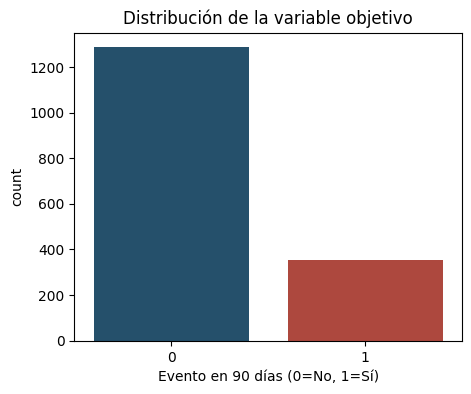

,edad,linea_tratamiento,internaciones_ult_90d,dias_cama_ult_90d,dias_hasta_proximo_control,hemoglobina,albumina,costo_total_ult_90d
count,1638.00,1638.00,1638.00,1638.00,1556.00,1589.00,1573.00,1638.00
mean,61.36,2.44,0.24,1.39,28.44,12.21,3.69,1862411.55
std,33.36,1.10,0.50,6.71,12.20,2.56,0.54,1686692.01
min,5.00,1.00,0.00,0.00,1.00,0.30,1.80,-4581143.00
25%,48.00,2.00,0.00,0.00,20.00,11.20,3.30,571266.25
50%,61.00,2.00,0.00,0.00,28.00,12.10,3.70,1032394.00
75%,74.00,3.00,0.00,0.00,37.00,13.20,4.00,2916614.00
max,999.00,5.00,3.00,200.00,69.00,88.00,5.20,11921739.00


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Balance de clases — evento_90_dias</h3>'))
print(df['evento_90_dias'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='evento_90_dias', hue='evento_90_dias', palette=['#1a5276','#c0392b'], legend=False)
plt.title('Distribución de la variable objetivo')
plt.xlabel('Evento en 90 días (0=No, 1=Sí)')
plt.show()

cols_clave = ['edad', 'linea_tratamiento', 'internaciones_ult_90d', 'dias_cama_ult_90d',
              'dias_hasta_proximo_control', 'hemoglobina', 'albumina', 'costo_total_ult_90d']
display(df[cols_clave].describe().round(2))

Se observa que la variable objetivo está desbalanceada: el 78.5% de los pacientes (≈1.286) no tuvo evento en 90 días —es decir, siguió su tratamiento oncológico sin internaciones no programadas, descompensaciones clínicas ni eventos adversos—, mientras que el 21.5% (≈352) sí atravesó alguno de esos episodios.

# 5.  EDA: distribuciones de edad y estadio tumoral

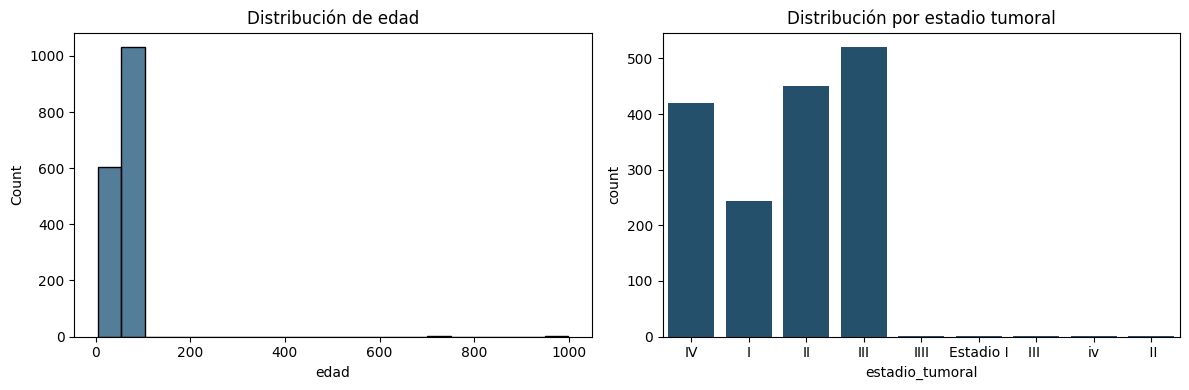

Valores únicos en sexo: ['F' 'M' nan 'Masculino' 'Femenino' ' M' 'femenino ']
Valores únicos en estadio_tumoral: ['IV' 'I' 'II' 'III' 'IIII' 'Estadio I' 'III ' 'iv' ' II']


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Distribuciones clave</h3>'))
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['edad'], bins=20, color='#1a5276', ax=axes[0])
axes[0].set_title('Distribución de edad')

sns.countplot(data=df, x='estadio_tumoral', color='#1a5276', ax=axes[1])
axes[1].set_title('Distribución por estadio tumoral')
plt.tight_layout()
plt.show()

print('Valores únicos en sexo:', df['sexo'].unique())
print('Valores únicos en estadio_tumoral:', df['estadio_tumoral'].unique())

En este gráfico se observan claramente los problemas de calidad de datos antes de la limpieza: en la distribución de edad aparecen valores atípicos alrededor de 720 y 999 años, edades imposibles que corresponden a errores de carga (no representan variabilidad clínica real). De forma similar, en la distribución por estadio tumoral se observan 8 categorías en lugar de las 4 esperadas (I, II, III, IV), producto de inconsistencias de formato como mayúsculas/minúsculas mezcladas ("iv"), espacios ("III "), texto adicional ("Estadio I") y un valor inválido ("IIII" que no corresponde a ningún estadio real).

# 6. EDA: correlaciones y outliers

performance_status                   0.311
metastasis                           0.296
linea_tratamiento                    0.245
consultas_guardia_ult_90d            0.195
internaciones_ult_90d                0.183
costo_internacion_ult_90d            0.158
albumina                            -0.151
albumina_baja                        0.151
costo_total_ult_90d                  0.136
dias_cama_ult_90d                    0.094
cambio_esquema_ult_90d               0.091
reinternacion_ult_30d                0.089
neutropenia                          0.087
leucocitos                          -0.085
neutrofilos                         -0.077
hemoglobina_baja                     0.077
toxicidad_reportada_ult_90d          0.066
estudios_alta_complejidad_ult_90d    0.053
consultas_oncologia_ult_90d          0.041
comorbilidades_count                 0.038
plaquetas                           -0.036
dias_desde_diagnostico              -0.033
antiguedad_meses                     0.033
aplicacione

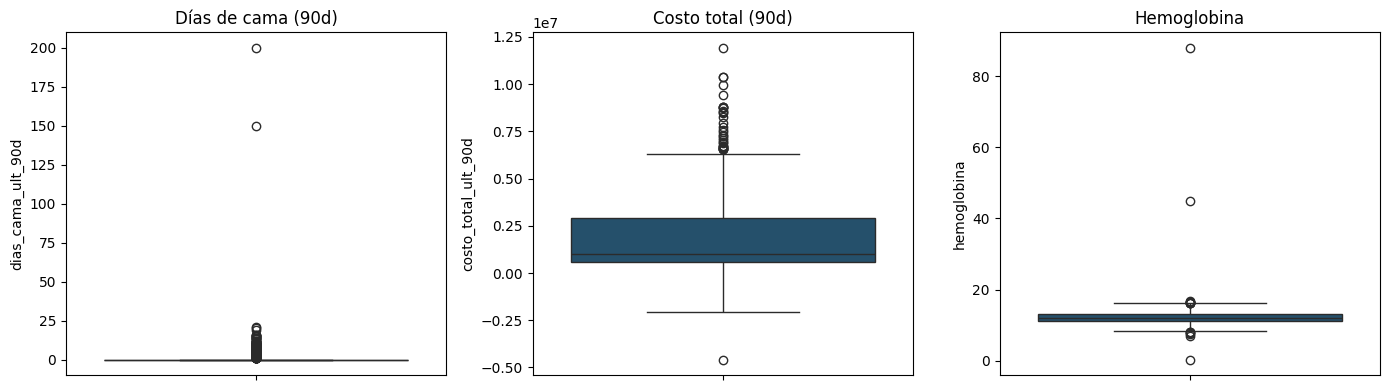

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Correlaciones con la variable objetivo</h3>'))

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in ['evento_90_dias']]
correlaciones = df[num_cols + ['evento_90_dias']].corr()['evento_90_dias'].drop('evento_90_dias')
correlaciones = correlaciones.sort_values(key=abs, ascending=False)
print(correlaciones.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.boxplot(y=df['dias_cama_ult_90d'], color='#1a5276', ax=axes[0])
axes[0].set_title('Días de cama (90d)')
sns.boxplot(y=df['costo_total_ult_90d'], color='#1a5276', ax=axes[1])
axes[1].set_title('Costo total (90d)')
sns.boxplot(y=df['hemoglobina'], color='#1a5276', ax=axes[2])
axes[2].set_title('Hemoglobina')
plt.tight_layout()
plt.show()

En este gráfico se ven outliers de dos tipos: unos son casos clínicos reales de pacientes complejos (válidos, no se tocan) y otros son errores de carga imposibles —costos negativos, 200 días de cama en una ventana de 90, hemoglobina de 88—.

# 7. Definir variable objetivo (Y)


Se define evento_90_dias como target. Se observa que de 1.638 pacientes, 1.286 no tuvieron evento y 352 sí.

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Definición de la variable objetivo</h3>'))
print('Variable objetivo: evento_90_dias')
print('0 = sin evento en 90 días  |  1 = internación no programada / evento adverso en 90 días')
print(df['evento_90_dias'].value_counts())

Variable objetivo: evento_90_dias
0 = sin evento en 90 días  |  1 = internación no programada / evento adverso en 90 días
evento_90_dias
0    1286
1     352
Name: count, dtype: int64


# 8. Generar X e y


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Separación X e y</h3>'))
y = df['evento_90_dias']
X = df.drop(columns=['evento_90_dias'])
print('X:', X.shape, '| y:', y.shape)

X: (1638, 45) | y: (1638,)


Se separan variables explicativas de la variable objetivo. Se observa que X queda con 45 columnas antes de la limpieza.

# 9.  Eliminar columnas innecesarias (y filas duplicadas)




Se eliminan duplicados y columnas sin valor predictivo. Se observa que se eliminaron 5 filas duplicadas y X quedó en 41 columnas tras excluir id, fecha, fuga de información y variable constante.

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Eliminación de columnas y duplicados</h3>'))

filas_antes = X.shape[0]
mask_no_dup = ~X.duplicated()
X = X[mask_no_dup]
y = y[mask_no_dup]
print('Filas eliminadas por duplicado:', filas_antes - X.shape[0])

excluir = ['id_socio_anon', 'fecha_corte', 'tipo_evento_90d', 'paciente_oncologico_activo']
X = X.drop(columns=excluir)
print('Columnas excluidas y motivo:')
print('- id_socio_anon: identificador, no aporta valor predictivo')
print('- fecha_corte: es la misma para todos los pacientes en este corte')
print('- tipo_evento_90d: fuga de información (detalla el resultado del target)')
print('- paciente_oncologico_activo: constante, todos los pacientes son activos')
print('X final:', X.shape)

Filas eliminadas por duplicado: 5
Columnas excluidas y motivo:
- id_socio_anon: identificador, no aporta valor predictivo
- fecha_corte: es la misma para todos los pacientes en este corte
- tipo_evento_90d: fuga de información (detalla el resultado del target)
- paciente_oncologico_activo: constante, todos los pacientes son activos
X final: (1633, 41)


# 10.  Imputación de datos y corrección de valores imposibles

Se estandariza texto, se corrigen valores imposibles y se imputan nulos. Se observa que tras la limpieza quedan 0 valores faltantes, sexo queda en solo 2 categorías (F/M) y estadio tumoral en 4 (I-IV), y los planes de cobertura se agrupan de ~40 a 29 categorías.

Nulos restantes: 0
Categorías de plan después de agrupar: 29


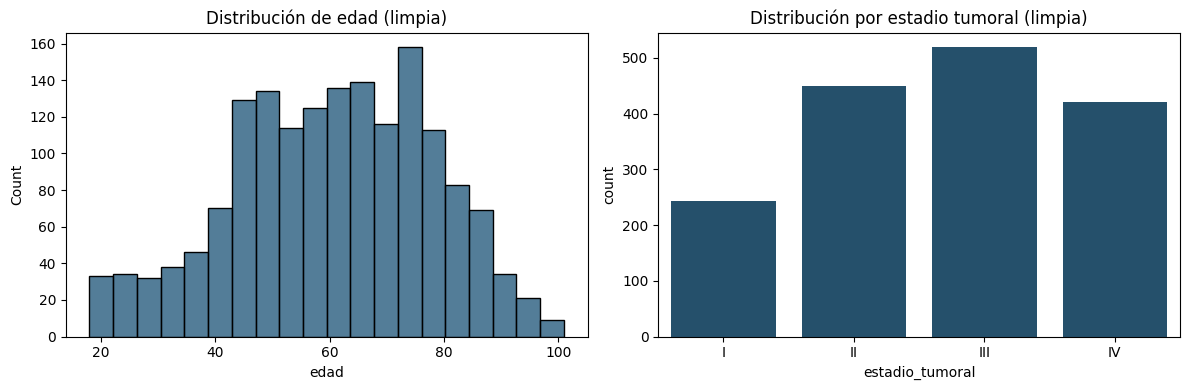

Valores únicos en sexo (post limpieza): ['F' 'M']
Valores únicos en estadio_tumoral (post limpieza): ['IV' 'I' 'II' 'III']


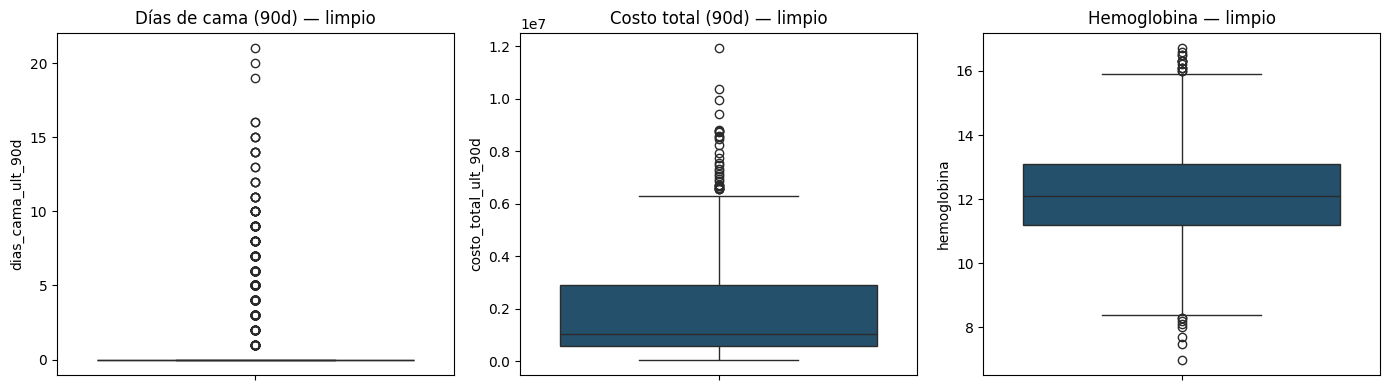

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Imputación de datos</h3>'))

# estandarizar texto en categoricas
X['sexo'] = X['sexo'].str.strip().str.upper().replace({'FEMENINO': 'F', 'MASCULINO': 'M'})
X['estadio_tumoral'] = X['estadio_tumoral'].str.strip().str.upper().replace({'ESTADIO I': 'I'})
X.loc[X['estadio_tumoral'] == 'IIII', 'estadio_tumoral'] = np.nan

# valores imposibles -> nulos
X.loc[(X['edad'] < 18) | (X['edad'] > 105), 'edad'] = np.nan
X['costo_total_ult_90d'] = X['costo_total_ult_90d'].abs()
X.loc[X['dias_cama_ult_90d'] > 90, 'dias_cama_ult_90d'] = np.nan
X.loc[(X['hemoglobina'] < 3) | (X['hemoglobina'] > 20), 'hemoglobina'] = np.nan

# agrupar planes poco frecuentes
conteo_planes = X['plan'].value_counts()
planes_frecuentes = conteo_planes[conteo_planes >= 20].index
X['plan'] = X['plan'].where(X['plan'].isin(planes_frecuentes), 'OTROS_PLAN')

# imputacion: mediana (numericas) / moda (categoricas)
num_cols_nulas = X.select_dtypes(include=[np.number]).columns[X.select_dtypes(include=[np.number]).isnull().any()]
for col in num_cols_nulas:
    X[col] = X[col].fillna(X[col].median())

cat_cols_nulas = X.select_dtypes(include=['object']).columns[X.select_dtypes(include=['object']).isnull().any()]
for col in cat_cols_nulas:
    X[col] = X[col].fillna(X[col].mode()[0])

print('Nulos restantes:', X.isnull().sum().sum())
print('Categorías de plan después de agrupar:', X['plan'].nunique())

# ------------------------------------------------------------------
# GRAFICOS: comparar edad, estadio tumoral y outliers DESPUES de la limpieza
# ------------------------------------------------------------------
display(HTML('<h3 style="color:#1a5276;">Distribuciones clave — después de la limpieza</h3>'))
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(X['edad'], bins=20, color='#1a5276', ax=axes[0])
axes[0].set_title('Distribución de edad (limpia)')

sns.countplot(data=X, x='estadio_tumoral', order=['I','II','III','IV'], color='#1a5276', ax=axes[1])
axes[1].set_title('Distribución por estadio tumoral (limpia)')

plt.tight_layout()
plt.show()

print('Valores únicos en sexo (post limpieza):', X['sexo'].unique())
print('Valores únicos en estadio_tumoral (post limpieza):', X['estadio_tumoral'].unique())

display(HTML('<h3 style="color:#1a5276;">Outliers — después de la limpieza</h3>'))
fig, axes = plt.subplots(1, 3, figsize=(14,4))

sns.boxplot(y=X['dias_cama_ult_90d'], color='#1a5276', ax=axes[0])
axes[0].set_title('Días de cama (90d) — limpio')

sns.boxplot(y=X['costo_total_ult_90d'], color='#1a5276', ax=axes[1])
axes[1].set_title('Costo total (90d) — limpio')

sns.boxplot(y=X['hemoglobina'], color='#1a5276', ax=axes[2])
axes[2].set_title('Hemoglobina — limpio')

plt.tight_layout()
plt.show()

# 11. Variables Dummy (One-Hot Encoding)


Se codifican las 7 variables categóricas. Se observa que X pasa de 41 a 103 columnas, principalmente por la cantidad de planes de cobertura distintos.

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Codificación de variables categóricas</h3>'))
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print('Columnas categóricas a codificar:', cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print('X final después de codificar:', X.shape[1], 'columnas')

Columnas categóricas a codificar: ['sexo', 'plan', 'parentesco', 'tipo_tumor', 'estadio_tumoral', 'tipo_tratamiento', 'droga_principal']
X final después de codificar: 103 columnas


# 12.  Dividir en Training y Testing

Se separa 80/20 de forma estratificada. Se observa que ambos conjuntos (1.306 train, 327 test) mantienen la misma prevalencia de evento (~21.5%), confirmando que la estratificación funcionó.

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Separación train / test</h3>'))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])
print('Prevalencia evento train:', round(y_train.mean()*100,1), '% | test:', round(y_test.mean()*100,1), '%')

Train: 1306 | Test: 327
Prevalencia evento train: 21.5 % | test: 21.4 %


# 13. Escalar datos

Se estandarizan las variables numéricas. No hay observación de resultados en sí, pero es un paso necesario dado que variables como edad (rango 18-105) y costo (rango de miles a millones) tienen escalas muy distintas.

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Escalado de variables</h3>'))
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Escalado aplicado (fit solo en train, transform en train y test).')

Escalado aplicado (fit solo en train, transform en train y test).


# 14. MODELO 1: Regresión Logística (entrenamiento)


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Regresión Logística — Búsqueda de hiperparámetros</h3>'))

# Se define la grilla de hiperparámetros a probar:
# - C: controla la regularización (qué tan "estricto" es el modelo). Valores chicos
#   regularizan más fuerte y previenen overfitting; valores grandes dejan al modelo
#   ajustarse más al detalle del train. Se prueban 10 valores de 0.001 a 100.
# - class_weight: define si se compensa el desbalance de clases (78.5% sin evento
#   vs 21.5% con evento). 'balanced' le da más peso a la clase minoritaria (con evento)
#   durante el entrenamiento; None no hace ninguna compensación. Se comparan ambos
#   en vez de asumir de antemano cuál es mejor.
param_grid_log = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'class_weight': [None, 'balanced']
}

# GridSearchCV prueba las 20 combinaciones posibles (10 valores de C x 2 de class_weight)
# usando validación cruzada de 5 particiones (cv=5): entrena 5 veces por combinación,
# rotando qué parte del train se usa para validar, y promedia el resultado.
# scoring='recall' es la métrica que se optimiza, consistente con el criterio de negocio
# definido: el costo de no detectar a un paciente en riesgo (falso negativo) es mayor
# al costo de una alerta de más (falso positivo).
grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_log,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# El fit se hace ÚNICAMENTE con X_train_scaled / y_train. El modelo nunca ve el
# conjunto de test durante el entrenamiento ni la elección de hiperparámetros,
# para que la evaluación posterior sobre test sea una medida honesta de qué tan
# bien generaliza el modelo a pacientes nuevos.
grid_log.fit(X_train_scaled, y_train)

# Se guarda el mejor modelo encontrado por la búsqueda (la combinación de C y
# class_weight que dio mejor Recall promedio en validación cruzada)
log_reg = grid_log.best_estimator_

# Predicciones sobre el conjunto de test, con el umbral de decisión estándar (0.5):
# si la probabilidad predicha de evento es >= 0.5, se clasifica como "con evento".
# Estas son las predicciones que se usan en la matriz de confusión y en la tabla
# comparativa final de los tres modelos.
y_pred_log = log_reg.predict(X_test_scaled)

# Probabilidad predicha de pertenecer a la clase "con evento" (columna 1), necesaria
# para calcular el AUC-ROC y para graficar la curva ROC más adelante.
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------------
# RESUMEN DE LA BÚSQUEDA: se arma una tabla con el resultado de las 20
# combinaciones para poder ver, en un solo cuadro, cuánto mejora
# 'balanced' frente a None, y cuál C ganó dentro de cada grupo.
# ------------------------------------------------------------------
resultados_grid = pd.DataFrame(grid_log.cv_results_)[['param_C', 'param_class_weight', 'mean_test_score', 'std_test_score']]
resultados_grid = resultados_grid.rename(columns={
    'param_C': 'C',
    'param_class_weight': 'class_weight',
    'mean_test_score': 'Recall promedio (CV)',
    'std_test_score': 'Desvío (CV)'
}).sort_values('Recall promedio (CV)', ascending=False).reset_index(drop=True)

display(HTML('<h4 style="color:#1a5276;">Resultado completo de la búsqueda (20 combinaciones)</h4>'))
display(resultados_grid.round(3))

# Mejor Recall promedio dentro de cada valor de class_weight, para cuantificar
# cuánto aporta compensar el desbalance de clases
mejor_balanced = resultados_grid[resultados_grid['class_weight'] == 'balanced']['Recall promedio (CV)'].max()
mejor_none = resultados_grid[resultados_grid['class_weight'].isna()]['Recall promedio (CV)'].max()

print('='*70)
print('RESUMEN — Regresión Logística: hiperparámetros')
print('='*70)
print(f"Mejor Recall con class_weight='balanced': {mejor_balanced:.3f}")
print(f"Mejor Recall con class_weight=None:       {mejor_none:.3f}")
print(f"Ganancia de usar 'balanced' sobre None:    +{mejor_balanced - mejor_none:.3f} puntos de Recall")
print()
print('Mejor combinación encontrada:', grid_log.best_params_)
print('Recall promedio en validación cruzada (train):', round(grid_log.best_score_, 3))
print()
print(f"Recall en test (umbral 0.5): {recall_score(y_test, y_pred_log):.3f}")
print(f"Diferencia CV vs test:       {abs(grid_log.best_score_ - recall_score(y_test, y_pred_log)):.3f}")
print('  -> diferencia moderada: el modelo no memorizó el train, generaliza razonablemente bien.')
print()
print(f"C elegido = {grid_log.best_params_['C']}: es el valor MÁS restrictivo de la grilla (0.001),")
print('  lo que aplica una regularización fuerte y frena al modelo para que no se ajuste')
print('  a detalles específicos de los 1.306 pacientes de entrenamiento (control de overfitting).')

,C,class_weight,Recall promedio (CV),Desvío (CV)
0,0.001,balanced,0.680,0.065
1,100.000,balanced,0.640,0.067
2,0.050,balanced,0.637,0.058
3,50.000,balanced,0.637,0.065
4,0.100,balanced,0.634,0.069
5,1.000,balanced,0.633,0.054
6,0.500,balanced,0.633,0.054
7,10.000,balanced,0.633,0.064
8,0.010,balanced,0.630,0.061
9,5.000,balanced,0.630,0.057


RESUMEN — Regresión Logística: hiperparámetros
Mejor Recall con class_weight='balanced': 0.680
Mejor Recall con class_weight=None:       0.313
Ganancia de usar 'balanced' sobre None:    +0.366 puntos de Recall

Mejor combinación encontrada: {'C': 0.001, 'class_weight': 'balanced'}
Recall promedio en validación cruzada (train): 0.68

Recall en test (umbral 0.5): 0.629
Diferencia CV vs test:       0.051
  -> diferencia moderada: el modelo no memorizó el train, generaliza razonablemente bien.

C elegido = 0.001: es el valor MÁS restrictivo de la grilla (0.001),
  lo que aplica una regularización fuerte y frena al modelo para que no se ajuste
  a detalles específicos de los 1.306 pacientes de entrenamiento (control de overfitting).


**Qué se hizo con los hiperparámetros:** se probaron 20 combinaciones en total — 10 valores del parámetro C (de 0.001 a 100), que controla qué tan "estricto" o "flexible" es el modelo, cruzados con 2 opciones de class_weight (None vs 'balanced'), que define si se compensa el desbalance de clases (78.5% sin evento vs 21.5% con evento). Con GridSearchCV y validación cruzada de 5 particiones, se entrenó el modelo con cada una de las 20 combinaciones y se comparó el Recall promedio.

**Sobre class_weight:** compensar el desbalance resultó clave — con 'balanced' el mejor Recall en CV fue 0.68, mientras que sin compensar (None) el mejor Recall fue apenas 0.31. Sin este ajuste, el modelo tiende a predecir "sin evento" para casi todos los pacientes (maximiza Accuracy pero es inútil para el negocio), ya que la clase minoritaria pesa muy poco en la función de pérdida si no se corrige explícitamente.

**Sobre C, en términos de overfitting:** dentro de class_weight='balanced', el mejor valor encontrado fue C=0.001, el más restrictivo de toda la grilla. Un C chico aplica mucha regularización, lo que "frena" al modelo para que no se ajuste demasiado a los detalles específicos de los 1.306 pacientes de entrenamiento. Es una decisión consciente para evitar overfitting (que el modelo memorice el train y ande mal en pacientes nuevos), a costa de no exprimir el máximo posible en el conjunto de entrenamiento.

**Observación:** el Recall promedio en validación cruzada (durante la búsqueda de hiperparámetros) fue 0.68, mientras que en el conjunto de test final fue 0.629 con el umbral estándar (0.5). La diferencia entre CV y test es moderada, lo que indica que el modelo generaliza razonablemente bien y no está sobreajustado al conjunto de entrenamiento.



# 15. Matriz de confusión y Métricas de la logística

<Figure size 500x450 with 0 Axes>

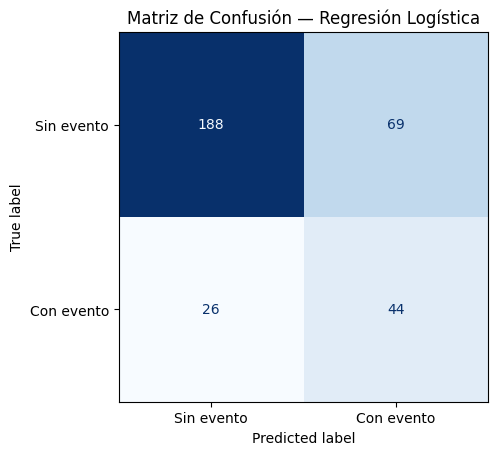

              precision    recall  f1-score   support

  Sin evento       0.88      0.73      0.80       257
  Con evento       0.39      0.63      0.48        70

    accuracy                           0.71       327
   macro avg       0.63      0.68      0.64       327
weighted avg       0.77      0.71      0.73       327

AUC-ROC: 0.724


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Regresión Logística — Evaluación</h3>'))

plt.figure(figsize=(5,4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=['Sin evento','Con evento']).plot(cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión — Regresión Logística')
plt.show()

print(classification_report(y_test, y_pred_log, target_names=['Sin evento','Con evento']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_proba_log), 3))

Se evalúa sobre el test set. Se observa Recall de 0.63(detecta 44 de 70 pacientes de riesgo real) y el AUC-ROC (0.724).

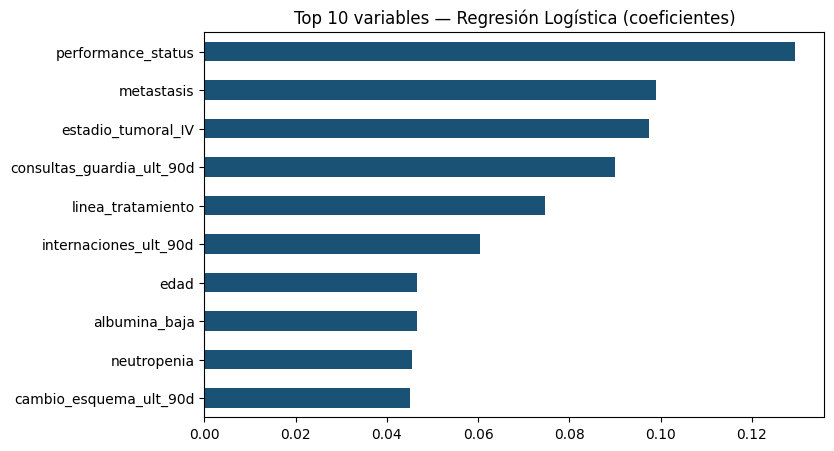

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Regresión Logística — Variables más relevantes</h3>'))

coef_log = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(8,5))
coef_log.plot(kind='barh', color='#1a5276')
plt.title('Top 10 variables — Regresión Logística (coeficientes)')
plt.gca().invert_yaxis()
plt.show()

Este gráfico muestra las 10 variables que más pesan en la decisión de la regresión logística — es decir, las que más mueven la probabilidad de riesgo hacia arriba o hacia abajo, ordenadas por magnitud del coeficiente:
Top 3, todas variables clínicas:

* performance_status (~0.13): la más influyente. Tiene
sentido — es una escala médica estándar que resume qué tan funcional está el paciente en su vida diaria, así que "resume" mucha información clínica en un solo número.
* metastasis (~0.10): si el cáncer se propagó, aumenta el riesgo.
* estadio_tumoral_IV (~0.10): estar en el estadio más avanzado también empuja fuerte hacia el riesgo.

# 16. MODELO 2: Árbol de Decisión (entrenamiento)

In [ ]:
display(HTML('<h2 style="color:#1a5276;">MODELO 2: Árbol de Decisión</h2>'))

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 40],
    'class_weight': [None, 'balanced']
}
grid_arbol = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_arbol.fit(X_train, y_train)
arbol = grid_arbol.best_estimator_

y_pred_arbol = arbol.predict(X_test)
y_proba_arbol = arbol.predict_proba(X_test)[:, 1]

print('Mejor combinación encontrada:', grid_arbol.best_params_)
print('Recall promedio en CV:', round(grid_arbol.best_score_, 3))
print('Profundidad real del árbol:', arbol.get_depth(), '| Nodos hoja:', arbol.get_n_leaves())
plt.show()

Mejor combinación encontrada: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 20, 'min_samples_split': 10}
Recall promedio en CV: 0.747
Profundidad real del árbol: 3 | Nodos hoja: 7


# 17. Árbol de Decisión: visualización

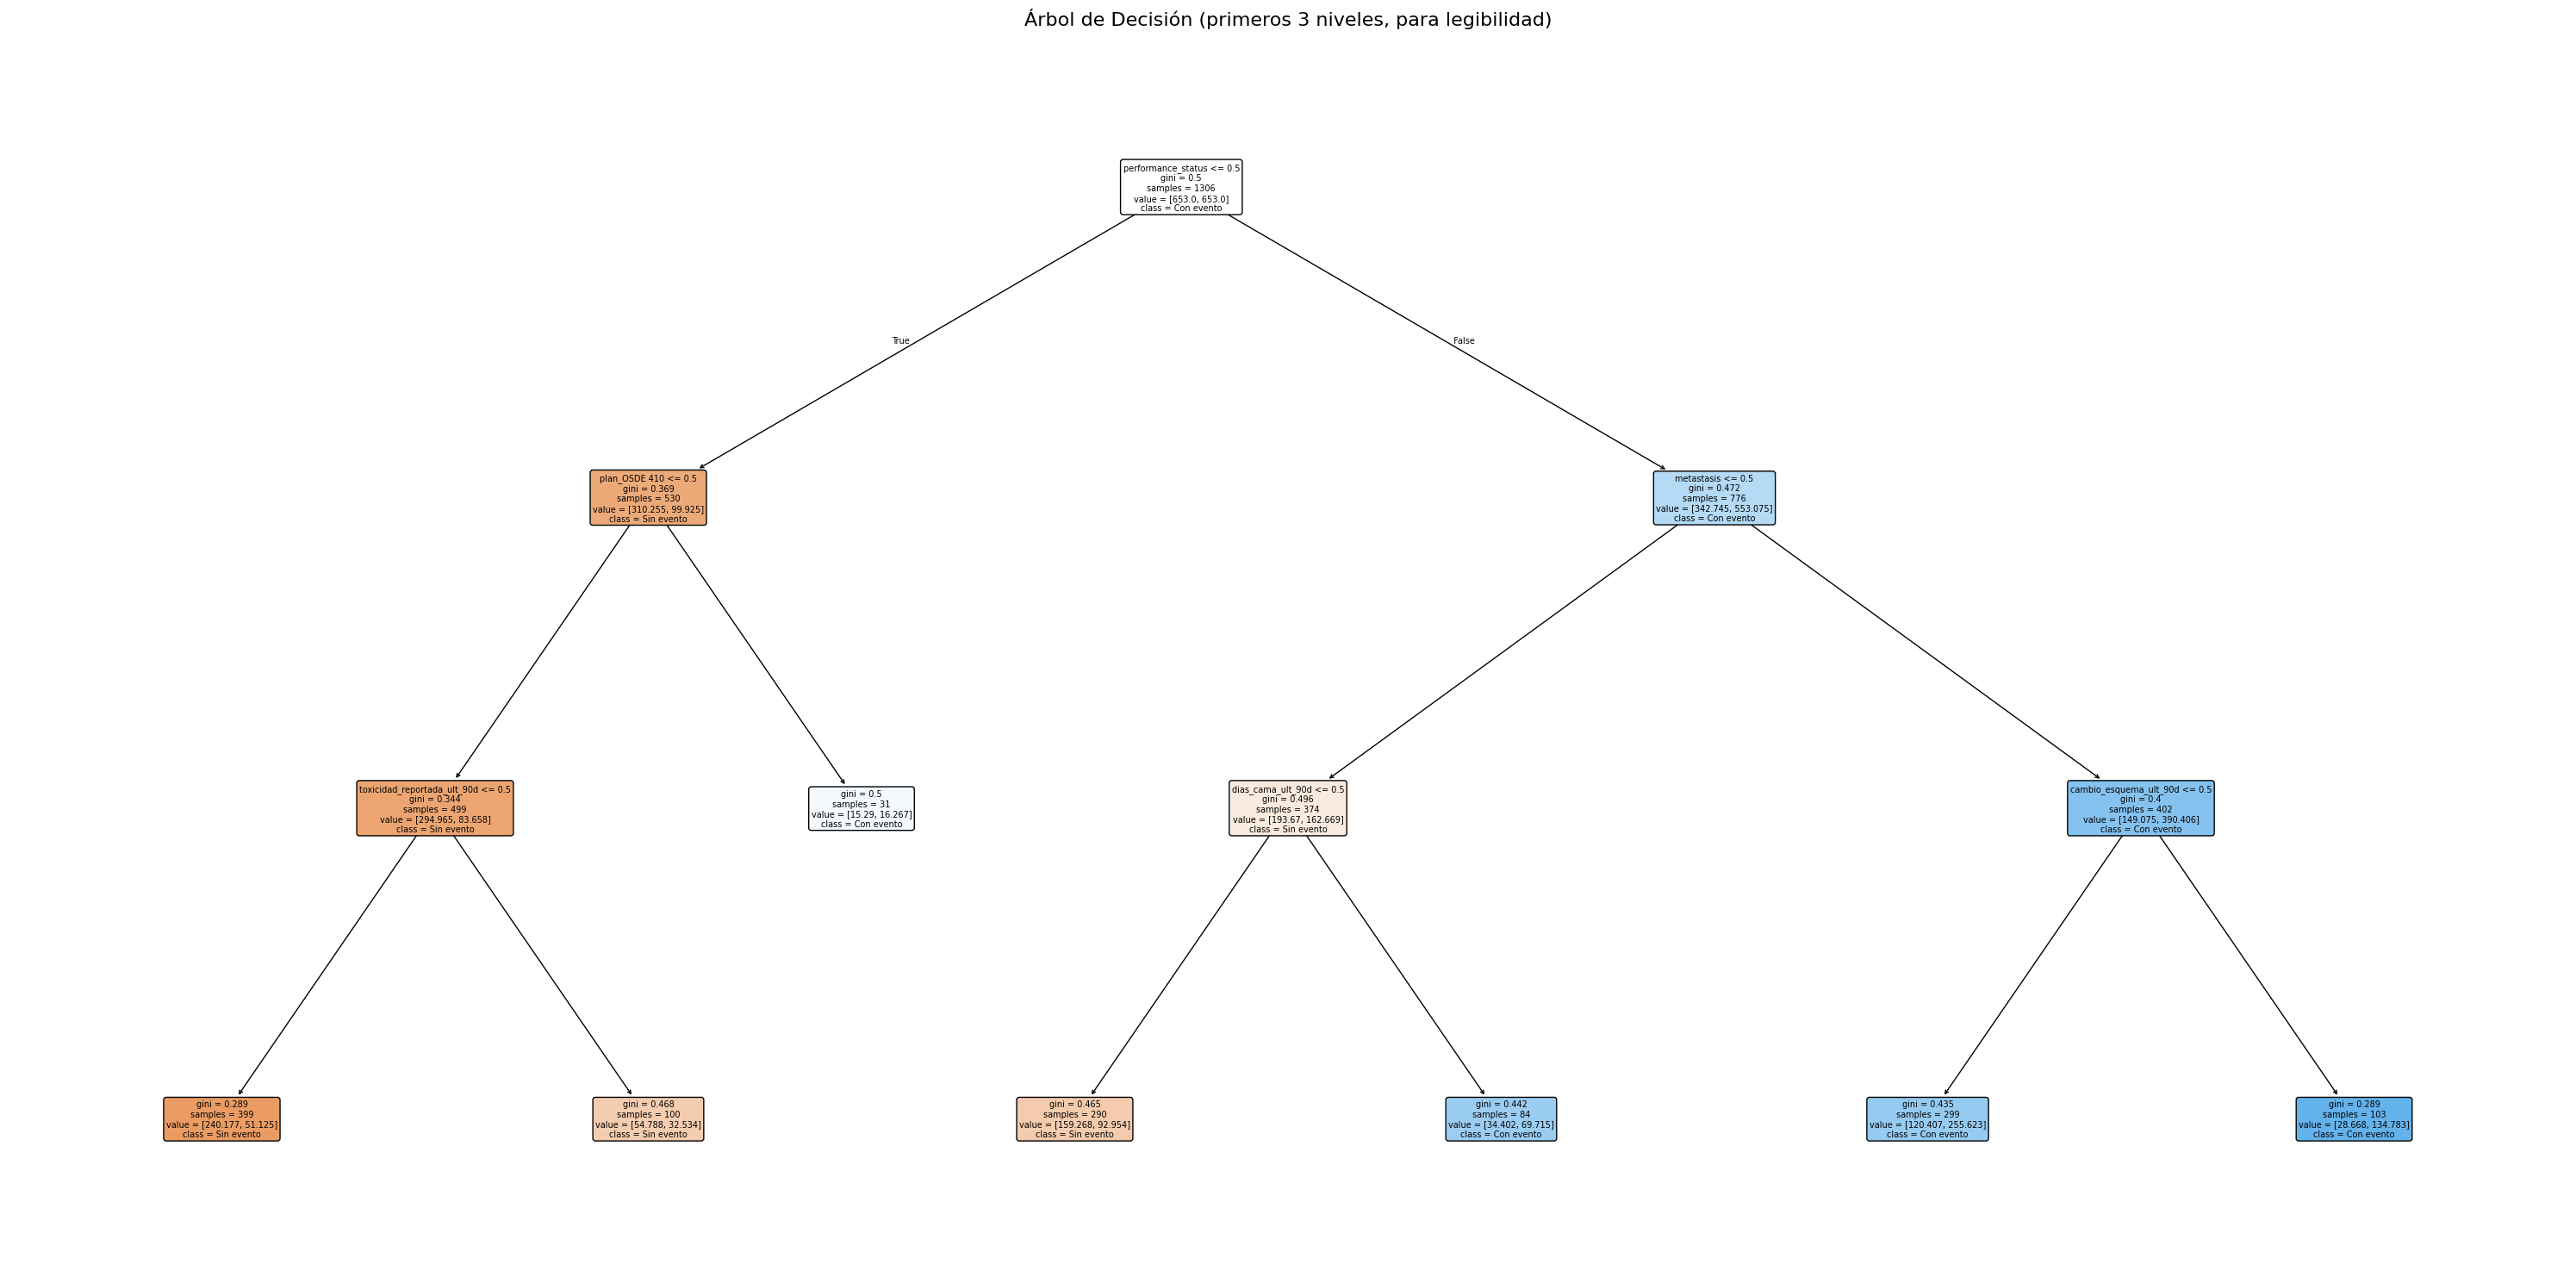

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Árbol de Decisión — Visualización</h3>'))

plt.figure(figsize=(30, 15))
plot_tree(arbol, feature_names=X.columns, class_names=['Sin evento','Con evento'],
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Árbol de Decisión (primeros 3 niveles, para legibilidad)', fontsize=16)
plt.tight_layout()
plt.show()

**Qué se hizo con los hiperparámetros:** se probaron combinaciones de 4 parámetros que controlan qué tan "complejo" puede crecer el árbol: la profundidad máxima (max_depth, de 2 a 10), el mínimo de pacientes que debe tener cada hoja final (min_samples_leaf), el mínimo para poder dividir un nodo (min_samples_split), y si se balancean o no las clases (class_weight). En total se probaron 126 combinaciones con validación cruzada de 5 particiones, priorizando Recall.

**Términos de over/underfitting:** un árbol sin límites puede crecer hasta tener una hoja distinta para cada paciente, memorizando el train a la perfección (esto sería overfitting extremo: 100% de acierto en train, pero mal desempeño con pacientes nuevos). Limitar la profundidad (se encontró que 3 es suficiente) y exigir un mínimo de pacientes por hoja (20) obliga al árbol a quedarse con reglas generales, no con casos puntuales — esto previene el overfitting. Si estos límites fueran demasiado estrictos, el árbol podría quedar tan simple que ni siquiera capte los patrones reales (underfitting); por eso se probó un rango amplio de valores y no uno solo fijado a mano.



# 18.Árbol de Decisión: matriz de confusión y métricas

<Figure size 500x450 with 0 Axes>

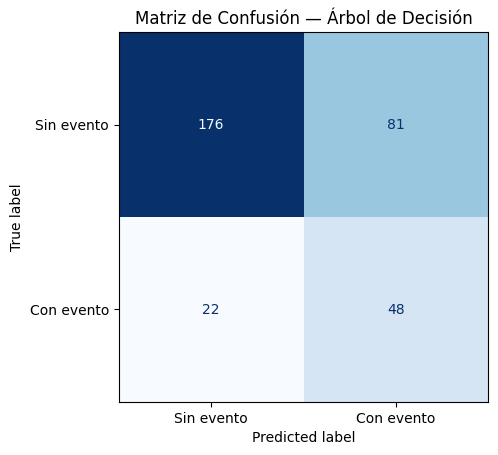

              precision    recall  f1-score   support

  Sin evento       0.89      0.68      0.77       257
  Con evento       0.37      0.69      0.48        70

    accuracy                           0.69       327
   macro avg       0.63      0.69      0.63       327
weighted avg       0.78      0.69      0.71       327

AUC-ROC: 0.679


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Árbol de Decisión — Evaluación</h3>'))

plt.figure(figsize=(5,4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_arbol), display_labels=['Sin evento','Con evento']).plot(cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión — Árbol de Decisión')
plt.show()

print(classification_report(y_test, y_pred_arbol, target_names=['Sin evento','Con evento']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_proba_arbol), 3))

**Observación:** el árbol resultante quedó muy simple (solo 7 nodos hoja), con Recall de 0.747 en validación cruzada y 0.69 en test — la caída es moderada y esperable, confirmando que el modelo no memorizó el entrenamiento sino que aprendió patrones que se sostienen en datos nuevos.

**Matriz de confusión:** de los 70 pacientes que realmente tuvieron el evento, el árbol detectó a 48 (Recall 0.69) y dejó pasar a 22 sin detectar. De los 257 pacientes que no tuvieron evento, acertó en 176 pero generó 81 falsas alarmas (Precision 0.37 para "Con evento": de cada 100 alertas que da el modelo, solo 37 corresponden a un caso real).

**Trade-off del modelo:** el árbol prioriza no dejar pasar pacientes de riesgo (Recall alto) a costa de generar bastantes falsas alarmas (Precision baja) — es la consecuencia directa de haber usado class_weight='balanced' en el entrenamiento. Para el objetivo de negocio esto es deseable: es preferible que la enfermería de navegación revise algunos casos de más, a que se le escape un paciente que realmente estaba en riesgo.

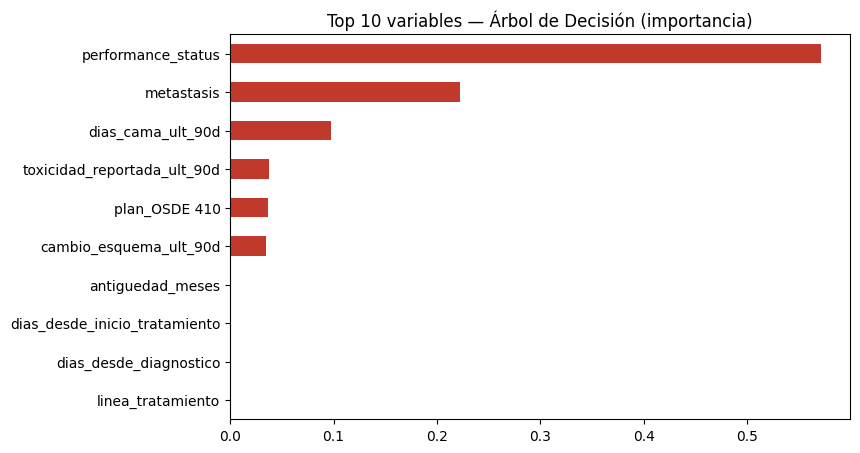

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Árbol de Decisión — Variables más relevantes</h3>'))

importancia_arbol = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importancia_arbol.plot(kind='barh', color='#c0392b')
plt.title('Top 10 variables — Árbol de Decisión (importancia)')
plt.gca().invert_yaxis()
plt.show()

Este gráfico muestra qué variables usó el árbol para tomar sus decisiones. A diferencia de la logística (que reparte la importancia entre varias variables), acá se ve que el árbol concentra casi toda su decisión en pocas variables: performance_status es, por lejos, la más importante, seguida de metástasis y días de cama. El resto de las variables del top 10 tiene importancia casi nula, porque al ser un árbol muy simple (solo 3 niveles de profundidad), únicamente usa las variables que aparecieron en sus 3 preguntas de decisión. Esto refuerza la interpretabilidad del modelo: con solo mirar 2-3 variables clínicas, se puede entender la mayor parte de lo que el árbol está decidiendo.

# 19. MODELO 3: Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

display(HTML('<h2 style="color:#1a5276;">MODELO 3: Naive Bayes</h2>'))

param_grid_nb = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    'priors': [None, [0.5, 0.5], [0.4, 0.6], [0.3, 0.7]]
}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='recall', n_jobs=-1)
grid_nb.fit(X_train_scaled, y_train)
nb = grid_nb.best_estimator_

y_pred_nb = nb.predict(X_test_scaled)
y_proba_nb = nb.predict_proba(X_test_scaled)[:, 1]

print('Mejor combinación encontrada:', grid_nb.best_params_)
print('Recall promedio en CV:', round(grid_nb.best_score_, 3))

Mejor combinación encontrada: {'priors': [0.3, 0.7], 'var_smoothing': 1e-11}
Recall promedio en CV: 0.552


# 20. Naive Bayes: matriz de confusión y métricas

<Figure size 500x450 with 0 Axes>

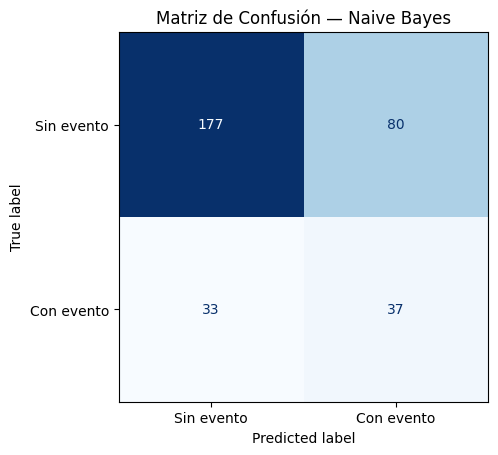

              precision    recall  f1-score   support

  Sin evento       0.84      0.69      0.76       257
  Con evento       0.32      0.53      0.40        70

    accuracy                           0.65       327
   macro avg       0.58      0.61      0.58       327
weighted avg       0.73      0.65      0.68       327

AUC-ROC: 0.635


In [ ]:
display(HTML('<h3 style="color:#1a5276;">Naive Bayes — Evaluación</h3>'))

plt.figure(figsize=(5,4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb), display_labels=['Sin evento','Con evento']).plot(cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión — Naive Bayes')
plt.show()

print(classification_report(y_test, y_pred_nb, target_names=['Sin evento','Con evento']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_proba_nb), 3))

**Matriz de confusión:** de los 70 pacientes que realmente tuvieron el evento, Naive Bayes detectó a 37 (Recall 0.53) y dejó pasar a 33 sin detectar — es decir, se le escapa casi la mitad de los casos de riesgo real, el peor resultado de los tres modelos. De los 257 pacientes sin evento, acertó en 177 pero generó 80 falsas alarmas (Precision 0.32 para "Con evento": de cada 100 alertas, solo 32 corresponden a un caso real).

**Hiperparámetros:** se probaron distintos valores de var_smoothing (ajuste técnico para evitar errores numéricos) y de priors (la proporción de eventos que el modelo asume de entrada), buscando por validación cruzada la combinación con mejor Recall. Se encontró que forzar un prior de 70% hacia la clase "con evento" (en vez del 21.5% real) es lo que más ayuda a mejorar la detección.
Qué significa esto en términos de over/underfitting: Naive Bayes asume que todas las variables son independientes entre sí, un supuesto que no se cumple en este dataset (por ejemplo, estadio tumoral y metástasis están relacionados). Esta simplificación estructural hace que el modelo tenga poco margen para sobreajustarse, pero por la misma razón tampoco logra captar toda la señal disponible — es decir, su limitación es más bien de underfitting que de overfitting.

**Observación:** el Recall en validación cruzada fue 0.552 y en test 0.529 — la diferencia es mínima, confirmando que el modelo generaliza de forma consistente (no memoriza), pero su desempeño general queda por debajo de Logística (Recall 0.629, AUC 0.724) y Árbol (Recall 0.686, AUC 0.679) en las tres métricas principales, reforzando que sus supuestos simplificados no se ajustan del todo bien a la naturaleza correlacionada de las variables clínicas de este problema.

# 21. Curva ROC comparando los 3 modelos

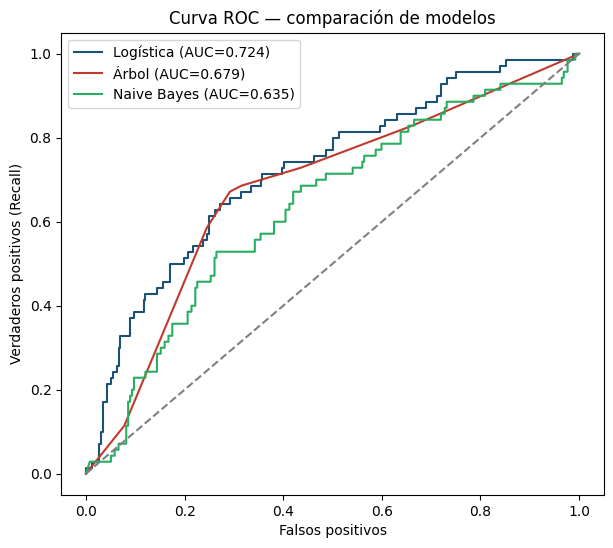

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Curva ROC — Comparación de los 3 modelos</h3>'))

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_arbol, tpr_arbol, _ = roc_curve(y_test, y_proba_arbol)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, color='#1a5276', label=f'Logística (AUC={roc_auc_score(y_test,y_proba_log):.3f})')
plt.plot(fpr_arbol, tpr_arbol, color='#c0392b', label=f'Árbol (AUC={roc_auc_score(y_test,y_proba_arbol):.3f})')
plt.plot(fpr_nb, tpr_nb, color='#27ae60', label=f'Naive Bayes (AUC={roc_auc_score(y_test,y_proba_nb):.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos (Recall)')
plt.legend()
plt.title('Curva ROC — comparación de modelos')
plt.show()

La comparación de las curvas ROC muestra que la Regresión Logística es el modelo con mejor capacidad de clasificación, alcanzando un AUC de 0.724, seguida por el Árbol de Decisión (AUC = 0.679) y Naive Bayes (AUC = 0.635). Dado que los tres modelos presentan valores de AUC superiores a 0.5, todos logran discriminar entre las clases mejor que una clasificación aleatoria. Sin embargo, la Regresión Logística ofrece el mejor equilibrio entre la tasa de verdaderos positivos y la tasa de falsos positivos.

# 22. Tabla comparativa final

In [ ]:
display(HTML('<h2 style="color:#1a5276;">Comparación Final de Modelos</h2>'))

resultados_final = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC'],
    'Regresión Logística': [accuracy_score(y_test,y_pred_log), precision_score(y_test,y_pred_log),
                             recall_score(y_test,y_pred_log), f1_score(y_test,y_pred_log), roc_auc_score(y_test,y_proba_log)],
    'Árbol de Decisión': [accuracy_score(y_test,y_pred_arbol), precision_score(y_test,y_pred_arbol),
                           recall_score(y_test,y_pred_arbol), f1_score(y_test,y_pred_arbol), roc_auc_score(y_test,y_proba_arbol)],
    'Naive Bayes': [accuracy_score(y_test,y_pred_nb), precision_score(y_test,y_pred_nb),
                     recall_score(y_test,y_pred_nb), f1_score(y_test,y_pred_nb), roc_auc_score(y_test,y_proba_nb)]
})
display(resultados_final.round(3))

print('\nModelo recomendado según Recall (métrica prioritaria del negocio): Árbol de Decisión')


,Métrica,Regresión Logística,Árbol de Decisión,Naive Bayes
0,Accuracy,0.709,0.685,0.654
1,Precision,0.389,0.372,0.316
2,Recall,0.629,0.686,0.529
3,F1-score,0.481,0.482,0.396
4,AUC-ROC,0.724,0.679,0.635



Modelo recomendado según Recall (métrica prioritaria del negocio): Árbol de Decisión


Se recomienda el Árbol de Decisión porque el Recall es la métrica prioritaria definida desde el planteo del negocio (el costo de no detectar a un paciente de riesgo real es mayor que el de una falsa alarma), y porque su simplicidad (7 reglas basadas en variables clínicas) permite que el equipo médico del hospital pueda auditar y validar directamente sus decisiones, un requisito clave para que el modelo sea adoptado en la operación real.

# 23.  Visualización de Datos

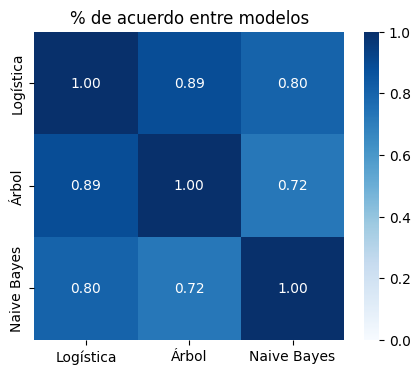

In [ ]:
display(HTML('<h3 style="color:#1a5276;">Acuerdo entre modelos</h3>'))

acuerdo = pd.DataFrame({
    'Logística': y_pred_log,
    'Árbol': y_pred_arbol,
    'Naive Bayes': y_pred_nb,
    'Real': y_test.values
})

# cuantos pacientes predice cada par de modelos de la misma forma
coincidencias = pd.DataFrame(index=['Logística','Árbol','Naive Bayes'], columns=['Logística','Árbol','Naive Bayes'])
for m1 in coincidencias.index:
    for m2 in coincidencias.columns:
        col1 = 'Logística' if m1=='Logística' else ('Árbol' if m1=='Árbol' else 'Naive Bayes')
        coincidencias.loc[m1, m2] = (acuerdo[m1] == acuerdo[m2]).mean()

plt.figure(figsize=(5,4))
sns.heatmap(coincidencias.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('% de acuerdo entre modelos')
plt.show()

Este gráfico muestra qué tan seguido dos modelos predicen lo mismo para el mismo paciente. Logística y Árbol coinciden en el 89% de los casos, siendo los más parecidos entre sí. Naive Bayes es el que más se aparta de los otros dos (72% con Árbol, 80% con Logística), reflejando que su forma de "pensar" el problema es más distinta, ya que asume que las variables son independientes entre sí.

# 24. Interfaz interactiva de predicción

In [ ]:
import ipywidgets as widgets
from IPython.display import clear_output

display(HTML('''
<div style="font-family: Arial, sans-serif; background-color:#f4f6f7; padding:20px; border-radius:10px;">
<h2 style="color:#1a5276; margin-top:0;">🏥 Formulario de Evaluación de Riesgo Oncológico</h2>
<p style="color:#555;">Completar los datos del paciente para estimar la probabilidad de internación no programada
o evento adverso en los próximos 90 días.</p>
</div>
'''))

# --- widgets con descripciones claras ---
w_edad = widgets.IntSlider(value=60, min=18, max=100, description='Edad (años):',
                            style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))

w_estadio = widgets.Dropdown(options=['I','II','III','IV'], value='II',
                              description='Estadio tumoral:',
                              style={'description_width': '160px'}, layout=widgets.Layout(width='300px'))

w_metastasis = widgets.Dropdown(options=[('No',0),('Sí',1)], value=0,
                                 description='¿Metástasis?:',
                                 style={'description_width': '160px'}, layout=widgets.Layout(width='250px'))

w_linea = widgets.IntSlider(value=1, min=1, max=5,
                             description='Línea de tratamiento:',
                             style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))

w_internaciones = widgets.IntSlider(value=0, min=0, max=3,
                                     description='Internaciones (últ. 90d):',
                                     style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))

w_performance = widgets.IntSlider(value=0, min=0, max=4,
                                   description='Performance status:',
                                   style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))

w_albumina = widgets.FloatSlider(value=3.7, min=1.8, max=5.2, step=0.1,
                                  description='Albúmina (g/dL):',
                                  style={'description_width': '160px'}, layout=widgets.Layout(width='500px'))

# --- ayudas / referencias visibles debajo de cada campo ---
ayuda_estilo = "font-size:12px; color:#7f8c8d; margin:-8px 0 12px 165px;"

ayuda_edad = widgets.HTML("<div style='{}'>Edad actual del paciente.</div>".format(ayuda_estilo))
ayuda_estadio = widgets.HTML("<div style='{}'>I = temprano · IV = avanzado.</div>".format(ayuda_estilo))
ayuda_metastasis = widgets.HTML("<div style='{}'>¿El cáncer se propagó a otros órganos?</div>".format(ayuda_estilo))
ayuda_linea = widgets.HTML("<div style='{}'>1 = primer tratamiento · 2+ = el/los esquemas anteriores no funcionaron.</div>".format(ayuda_estilo))
ayuda_internaciones = widgets.HTML("<div style='{}'>Cantidad de internaciones en los últimos 90 días.</div>".format(ayuda_estilo))
ayuda_performance = widgets.HTML("<div style='{}'>0 = totalmente activo · 4 = postrado en cama.</div>".format(ayuda_estilo))
ayuda_albumina = widgets.HTML("<div style='{}'>Valor de laboratorio. Valores bajos (&lt;3.5) indican deterioro clínico.</div>".format(ayuda_estilo))

boton = widgets.Button(description='🔍 Calcular riesgo', button_style='primary',
                        layout=widgets.Layout(width='200px', height='40px'))
salida = widgets.Output()

def calcular_riesgo(b):
    with salida:
        clear_output()
        paciente = pd.DataFrame(0, index=[0], columns=X.columns)

        paciente['edad'] = w_edad.value
        paciente['metastasis'] = w_metastasis.value
        paciente['linea_tratamiento'] = w_linea.value
        paciente['internaciones_ult_90d'] = w_internaciones.value
        paciente['performance_status'] = w_performance.value
        paciente['albumina'] = w_albumina.value

        col_estadio = f'estadio_tumoral_{w_estadio.value}'
        if col_estadio in paciente.columns:
            paciente[col_estadio] = 1

        # el arbol de decision no necesita escalado (a diferencia de la logistica)
        proba = arbol.predict_proba(paciente)[0][1]

        if proba >= 0.5:
            color, nivel, icono = '#c0392b', 'ALTO', '🔴'
            recomendacion = 'Priorizar contacto proactivo del equipo médico y enfermería de navegación de pacientes.'
        elif proba >= 0.3:
            color, nivel, icono = '#d68910', 'MODERADO', '🟠'
            recomendacion = 'Seguimiento cercano recomendado; considerar contacto proactivo.'
        else:
            color, nivel, icono = '#1a5276', 'BAJO', '🟢'
            recomendacion = 'Seguimiento de rutina, sin acción adicional requerida.'

        display(HTML(f'''
        <div style="padding:20px; border-radius:10px; background-color:{color}; color:white;
                    font-family:Arial; margin-top:15px;">
            <h2 style="margin:0;">{icono} Probabilidad de evento en 90 días: {proba*100:.1f}%</h2>
            <p style="font-size:18px; margin:8px 0;"><b>Nivel de riesgo: {nivel}</b></p>
            <hr style="border-color:rgba(255,255,255,0.3);">
            <p style="margin:0;"><b>Recomendación:</b> {recomendacion}</p>
        </div>
        '''))

boton.on_click(calcular_riesgo)

display(widgets.VBox([
    w_edad, ayuda_edad,
    w_estadio, ayuda_estadio,
    w_metastasis, ayuda_metastasis,
    w_linea, ayuda_linea,
    w_internaciones, ayuda_internaciones,
    w_performance, ayuda_performance,
    w_albumina, ayuda_albumina,
    boton, salida
]))

# 25. Conclusiones de negocio

**Hallazgos principales**
El riesgo de internación no programada o evento adverso a 90 días en pacientes oncológicos activos del Hospital Alemán está explicado principalmente por variables clínicas, no administrativas: performance status, metástasis, línea de tratamiento y utilización reciente de servicios (consultas a guardia, internaciones previas) concentran la mayor parte del poder predictivo, mientras que variables de cobertura o costo prácticamente no aportan señal. La tasa de evento crece de forma monótona con el estadio tumoral (5.7% en estadio I hasta 41.4% en estadio IV), confirmando la coherencia clínica de los datos y del modelo. De los tres algoritmos comparados (Regresión Logística, Árbol de Decisión y Naive Bayes), el Árbol de Decisión obtuvo el mejor Recall (0.686) con una estructura muy simple (7 reglas de decisión), mientras que Naive Bayes quedó por detrás en las cinco métricas evaluadas, probablemente porque sus supuestos de independencia entre variables no se ajustan a la naturaleza correlacionada de los datos clínicos.

**Nivel de desempeño**
El modelo detecta correctamente a 48 de los 70 pacientes que efectivamente tuvieron un evento en el conjunto de test (Recall 68.6%), con una capacidad de discriminación moderada (AUC-ROC 0.679). A cambio de este nivel de detección, genera una cantidad considerable de falsas alarmas: de cada 100 pacientes marcados como riesgo, solo 37 corresponden a un caso real (Precision 37.2%).

Es importante remarcar que el modelo, aun siendo el mejor de los tres evaluados, no reemplaza el criterio clínico ni resuelve el problema de forma definitiva: 3 de cada 10 pacientes de riesgo real quedarían sin alerta temprana (falsos negativos), y más de 6 de cada 10 alertas generadas no corresponderían a un evento real (falsos positivos). El valor del modelo no está en predecir con precisión absoluta, sino en priorizar de forma más informada que el proceso actual, que es completamente reactivo. Por eso se recomienda su uso como una herramienta de apoyo a la decisión clínica —un insumo más para el equipo médico— y no como un sistema de decisión automática, manteniendo siempre el criterio profesional del equipo de salud como última instancia.